##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [2]:
conda install pytorch torchvision torchaudio -c pytorch

Retrieving notices: ...working... done
Channels:
 - pytorch
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\khulo\anaconda3\envs\cv_lab

  added / updated specs:
    - pytorch
    - torchaudio
    - torchvision


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    brotlicffi-1.2.0.0         |  py312h885b0b7_0         348 KB
    certifi-2026.4.22          |  py312haa95532_0         133 KB
    cffi-2.0.0                 |  py312h02ab6af_1         291 KB
    charset-normalizer-3.4.4   |  py312haa95532_0         121 KB
    filelock-3.20.3            |  py312haa95532_0          38 KB
    freetype-2.14.1            |       hfbffc0b_0         514 KB
    gmp-6.3.0                  |       h537511b_0         330 KB
    gmpy2-2.2.2                |  py312h8598115_0         212 KB
    idna-3.11                  |  py312haa95532_

In [2]:
pip install transformers hugginface-hub


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement hugginface-hub (from versions: none)
ERROR: No matching distribution found for hugginface-hub


In [4]:
%pip install transformers scikit-learn pillow

  Using cached transformers-5.8.1-py3-none-any.whl.metadata (33 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    -----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.14.0 which is incompatible.


In [2]:
import os
from collections import Counter
from contextlib import nullcontext

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import sklearn.cluster._kmeans as sklearn_kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel

# Local workaround for a macOS/OpenBLAS threadpoolctl issue
sklearn_kmeans.threadpool_info = lambda: []
sklearn_kmeans.threadpool_limits = lambda *args, **kwargs: nullcontext()

MODEL_NAME = "facebook/dinov2-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
backbone = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
backbone.eval()

pet_data = OxfordIIITPet(
    root="data/oxford-iiit-pet",
    split="trainval",
    target_types="category",
    download=True,
)

CAT_BREEDS = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx",
}

def pet_type(category_id):
    return "cat" if pet_data.classes[category_id] in CAT_BREEDS else "dog"

def collect_subset(dataset, per_label=10):
    cats, dogs = [], []
    for img, category in dataset:
        label = pet_type(category)
        breed = dataset.classes[category]
        
        if label == "cat" and len(cats) < per_label:
            cats.append((img.convert("RGB"), label, breed))
        elif label == "dog" and len(dogs) < per_label:
            dogs.append((img.convert("RGB"), label, breed))
            
        if len(cats) == per_label and len(dogs) == per_label:
            break
            
    return [item for pair in zip(cats, dogs) for item in pair]

@torch.no_grad()
def encode_cls(image):
    encoded = processor(images=image, return_tensors="pt").to(DEVICE)
    tokens = backbone(**encoded).last_hidden_state
    vector = tokens[:, 0, :]
    return F.normalize(vector, p=2, dim=1).cpu().numpy().reshape(-1)

samples = collect_subset(pet_data, per_label=10)
X = np.asarray([encode_cls(image) for image, _, _ in samples])
labels = np.asarray([label for _, label, _ in samples])
y_true = np.where(labels == "cat", 0, 1)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

cluster_to_class = {}
for cluster in sorted(set(clusters)):
    values = y_true[clusters == cluster]
    cluster_to_class[cluster] = Counter(values).most_common(1)[0][0]

y_pred = np.asarray([cluster_to_class[cluster] for cluster in clusters])
pred_names = np.where(y_pred == 0, "cat", "dog")

print(f"CLS feature shape: {X.shape}")
print(f"Balanced sample counts: {dict(Counter(labels))}")
print(f"K-Means accuracy: {accuracy_score(y_true, y_pred):.2%}")
print("\nConfusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print("\nDetailed Predictions:")

for i, (_, truth, breed) in enumerate(samples, start=1):
    print(f"{i:02d}. {breed:24s} true={truth:3s} cluster={clusters[i - 1]} predicted={pred_names[i - 1]}")

print("=" * 65)
print(f"CLS Feature Shape: {X.shape} (20 Images, 384 Dimensions)")
print(f"Dataset Balance  : {dict(Counter(labels))}")
print(f"K-Means Accuracy  : {accuracy_score(y_true, y_pred):.2%}")
print("=" * 65)
print("\nCONFUSION MATRIX:")
print(f"               Predicted CAT    Predicted DOG")
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print(f"Actual CAT         {cm[0][0]:<16}{cm[0][1]}")
print(f"Actual DOG         {cm[1][0]:<16}{cm[1][1]}")
print("\n" + "=" * 65)
print(f"{'No.':<4}{'Breed Name':<22}{'True Label':<12}{'Predicted':<12}{'Status':<10}")
print("=" * 65)

for i, (_, truth, breed) in enumerate(samples, start=1):
    pred = pred_names[i - 1]
    status = "Correct" if truth == pred else "Wrong"
    print(f"{i:02d}  {breed:<22}{truth:<12}{pred:<12}{status:<10}")
print("=" * 65)

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 13671.01it/s]


CLS feature shape: (20, 384)
Balanced sample counts: {np.str_('cat'): 10, np.str_('dog'): 10}
K-Means accuracy: 100.00%

Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[10  0]
 [ 0 10]]

Detailed Predictions:
01. Abyssinian               true=cat cluster=1 predicted=cat
02. American Bulldog         true=dog cluster=0 predicted=dog
03. Abyssinian               true=cat cluster=1 predicted=cat
04. American Bulldog         true=dog cluster=0 predicted=dog
05. Abyssinian               true=cat cluster=1 predicted=cat
06. American Bulldog         true=dog cluster=0 predicted=dog
07. Abyssinian               true=cat cluster=1 predicted=cat
08. American Bulldog         true=dog cluster=0 predicted=dog
09. Abyssinian               true=cat cluster=1 predicted=cat
10. American Bulldog         true=dog cluster=0 predicted=dog
11. Abyssinian               true=cat cluster=1 predicted=cat
12. American Bulldog         true=dog cluster=0 predicted=dog
13. Abyssinian          

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights: 100%|██████████| 225/225 [00:00<00:00, 14990.36it/s]


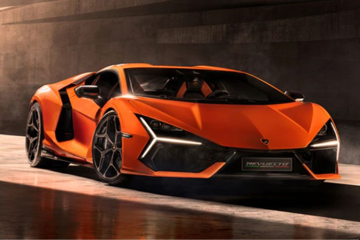

Model ID  : facebook/dinov2-small-imagenet1k-1-layer
Local Image: C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab10-visual-representations\Sport_Car.png
Rank  ImageNet Label                     Confidence
1     sports car                         77.65%
2     racer                              19.28%
3     car wheel                          1.98%
4     convertible                        0.77%
5     grille                             0.24%


In [6]:
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

image_processor = AutoImageProcessor.from_pretrained(MODEL_ID)
classifier = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(DEVICE)
classifier.eval()

image_path = r"C:\Users\khulo\Desktop\arti560-computer-vision-labs\lab10-visual-representations\Sport_Car.png"
image = Image.open(image_path).convert("RGB")

display(image.resize((360, 240)))

inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    logits = classifier(**inputs).logits[0]
    probs = torch.softmax(logits, dim=0)
    top_probs, top_ids = torch.topk(probs, 5)

print("=" * 55)
print(f"Model ID  : {MODEL_ID}")
print(f"Local Image: {image_path}")
print("=" * 55)
print(f"{'Rank':<6}{'ImageNet Label':<35}{'Confidence':<10}")
print("=" * 55)

for rank, (idx, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
    label = classifier.config.id2label[idx]
    clean_label = label.split(",")[0] if "," in label else label
    print(f"{rank:<6}{clean_label:<35}{prob:.2%}")
print("=" * 55)